In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
pd.set_option('display.max_columns',None)

In [ ]:
df = pd.read_csv("/content/gurgaon_properties_cleaned_v2.csv")

In [ ]:
df.head()

,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,latitude,longitude
0,dlf the magnolias,Sector 42,45.00,70312.0,6400,Super Built-up area 6400(594.58 sq.m.)Built-up...,4,4,3+,14,North-East,Moderately Old,6400.0,6000.00,5400.0,1,1,0,1,1,Furnished,1,28.454042,77.098740
1,godrej meridien,Sector 106,2.85,15364.0,1855,Super Built-up area 1855(172.34 sq.m.) sqft,3,3,3,8,East,Relatively New,1855.0,NaN,NaN,1,1,0,1,1,Unknown,5,28.508181,76.986806
2,experion windchants,Sector 112,6.25,16609.0,3763,Super Built-up area 3763(349.59 sq.m.)Built-up...,3,5,3,6,North,Moderately Old,3763.0,2873.18,NaN,0,1,0,0,0,Semi-Furnished,0,28.518719,77.014458
3,godrej 101,Sector 79,3.50,16471.0,2125,Super Built-up area 2125(197.42 sq.m.)Carpet a...,3,3,3,11,North,Under Construction,2125.0,NaN,1141.0,0,1,0,0,0,Unknown,0,28.359337,76.969227
4,dlf new town heights 1,Sector 90,2.85,10451.0,2727,Super Built-up area 2727(253.35 sq.m.)Built-up...,4,4,3+,4,North-West,Moderately Old,2727.0,2725.00,2721.0,0,1,0,1,0,Semi-Furnished,21,28.403442,76.930775


In [ ]:
df.shape

(1563, 24)

# price

/tmp/ipykernel_11640/444587821.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price'])


<Axes: xlabel='price', ylabel='Density'>

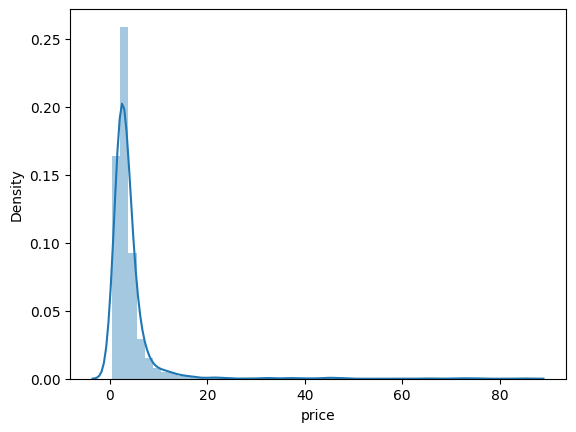

In [ ]:
sns.distplot(df['price'])

<Axes: ylabel='price'>

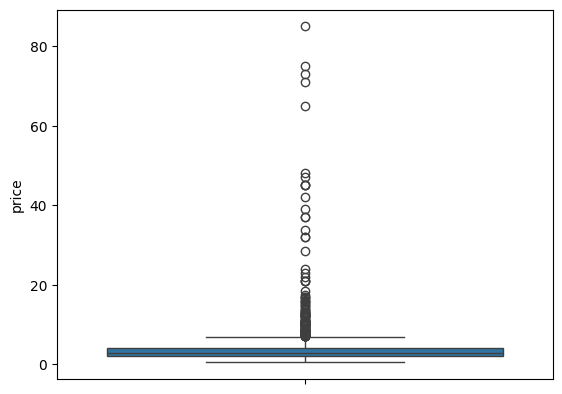

In [ ]:
sns.boxplot(df['price'])

In [ ]:
# Calculate the IQR for the 'price' column
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers.shape[0]
outliers_price_stats = outliers['price'].describe()

num_outliers, outliers_price_stats

(134,
 count    134.000000
 mean      15.833806
 std       14.888370
 min        6.950000
 25%        7.912500
 50%       10.320000
 75%       14.950000
 max       85.000000
 Name: price, dtype: float64)

In [ ]:
outliers.sort_values('price',ascending=False).head(20)

,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,latitude,longitude
1054,dlf the magnolias,Sector 42,85.00,78704.0,10800,Carpet area: 10800 (1003.35 sq.m.) sqft,5,5,2,8,East,Relatively New,NaN,NaN,10800.0,1,1,0,0,1,Furnished,3,28.460428,77.103181
887,dlf the camellias,DLF Golf Course,75.00,101351.0,7400,Super Built-up area 7400(687.48 sq.m.)Carpet a...,4,8,3+,10,North-East,Relatively New,7400.0,NaN,6000.0,1,1,1,1,0,Furnished,21,28.451320,77.100660
253,dlf the camellias,DLF Golf Course,73.00,98649.0,7400,Super Built-up area 7400(687.48 sq.m.)Carpet a...,4,8,3+,7,North-East,Relatively New,7400.0,NaN,6000.0,1,1,1,1,0,Furnished,0,28.451320,77.100660
267,dlf the camellias,Sector 42,71.00,91026.0,7800,Super Built-up area 7800(724.64 sq.m.) sqft,3,4,3,1,North-East,Relatively New,7800.0,NaN,NaN,1,1,1,1,0,Furnished,21,28.451180,77.099913
587,dlf the camellias,Sector 42,65.00,87838.0,7400,Super Built-up area 7400(687.48 sq.m.)Carpet a...,4,8,3+,8,North-East,Relatively New,7400.0,NaN,5500.0,1,1,1,1,0,Furnished,24,28.451320,77.100660
437,dlf the magnolias,Sector 42,48.00,75591.0,6350,Super Built-up area 6350(589.93 sq.m.)Built-up...,4,4,3+,10,North-East,Relatively New,6350.0,5760.0,4896.0,1,1,0,1,1,Unknown,0,28.458148,77.100545
92,dlf the magnolias,Sector 42,47.10,73594.0,6400,Super Built-up area 6400(594.58 sq.m.) sqft,4,4,3,7,North-East,Moderately Old,6400.0,NaN,NaN,1,1,1,1,0,Furnished,25,28.458570,77.100309
0,dlf the magnolias,Sector 42,45.00,70312.0,6400,Super Built-up area 6400(594.58 sq.m.)Built-up...,4,4,3+,14,North-East,Moderately Old,6400.0,6000.0,5400.0,1,1,0,1,1,Furnished,1,28.454042,77.098740
790,dlf the magnolias,DLF Golf Course,45.00,70312.0,6400,Super Built-up area 6400(594.58 sq.m.)Carpet a...,4,4,3+,5,North-East,Relatively New,6400.0,NaN,5000.0,1,1,1,1,0,Furnished,24,28.455419,77.098811
1071,dlf the magnolias,DLF Golf Course,45.00,70312.0,6400,Super Built-up area 6400(594.58 sq.m.)Carpet a...,4,4,3+,10,North-East,Moderately Old,6400.0,NaN,5500.0,1,1,1,1,0,Furnished,13,28.455642,77.099053


In [ ]:
# on the basis of price col we can say that there are some genuine outliers but there are some data erros as well

# price_per_sqft

/tmp/ipykernel_11640/2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

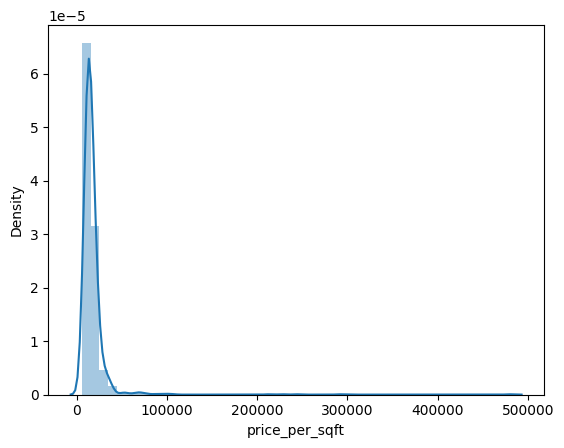

In [ ]:
sns.distplot(df['price_per_sqft'])

<Axes: ylabel='price_per_sqft'>

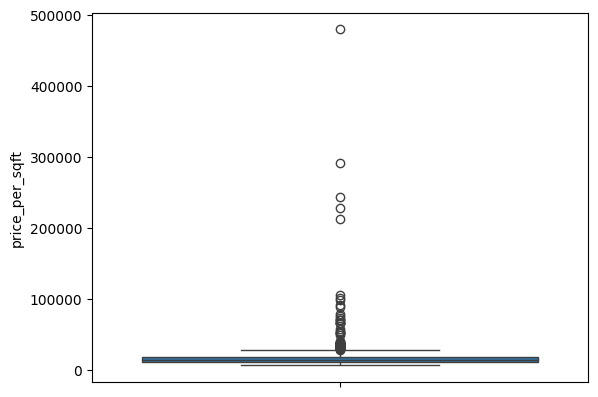

In [ ]:
sns.boxplot(df['price_per_sqft'])

In [ ]:
# Calculate the IQR for the 'price' column
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_sqft = df[(df['price_per_sqft'] < lower_bound) | (df['price_per_sqft'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers_sqft.shape[0]
outliers_price_stats = outliers_sqft['price_per_sqft'].describe()

num_outliers, outliers_price_stats

(93,
 count        93.000000
 mean      56125.419355
 std       63439.646366
 min       28428.000000
 25%       31194.000000
 50%       35237.000000
 75%       52500.000000
 max      480000.000000
 Name: price_per_sqft, dtype: float64)

In [ ]:
outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)

/tmp/ipykernel_11640/205471443.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)


In [ ]:
outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])

/tmp/ipykernel_11640/3686006548.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])


In [ ]:
outliers_sqft['price_per_sqft'].describe()

,price_per_sqft
count,93.000000
mean,41188.870968
std,17367.851513
min,11778.000000
25%,30612.000000
50%,34667.000000
75%,39673.000000
max,101351.000000


In [ ]:
df.update(outliers_sqft)

/tmp/ipykernel_11640/2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

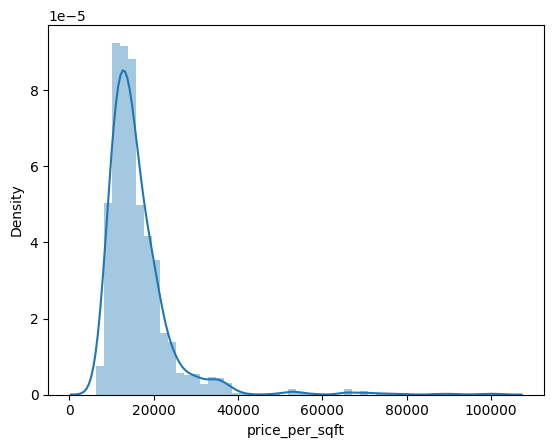

In [ ]:
sns.distplot(df['price_per_sqft'])

<Axes: ylabel='price_per_sqft'>

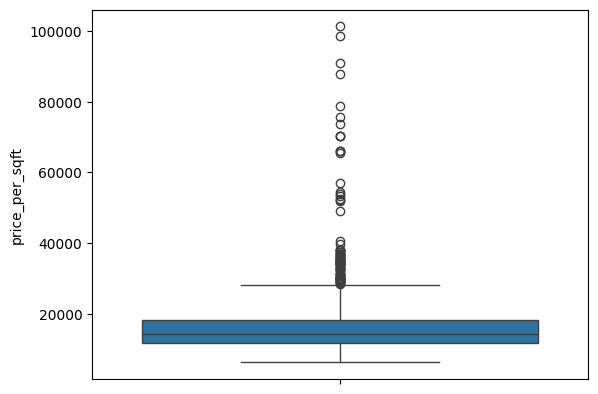

In [ ]:
sns.boxplot(df['price_per_sqft'])

In [ ]:
df[df['price_per_sqft'] > 40000].shape

(23, 24)

In [ ]:
df = df[df['price_per_sqft'] < 39000]

<Axes: xlabel='price_per_sqft'>

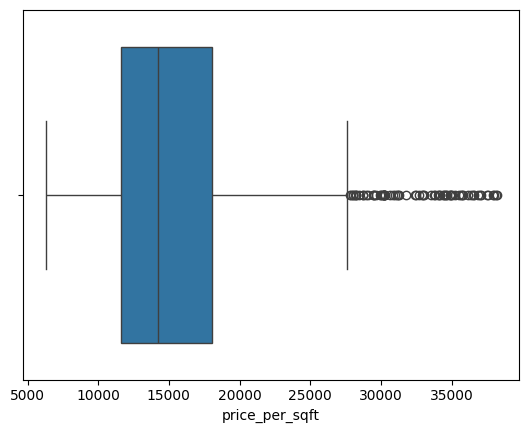

In [ ]:
sns.boxplot(x=df['price_per_sqft'])

In [ ]:
df.shape

(1539, 24)

# area

/tmp/ipykernel_11640/91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

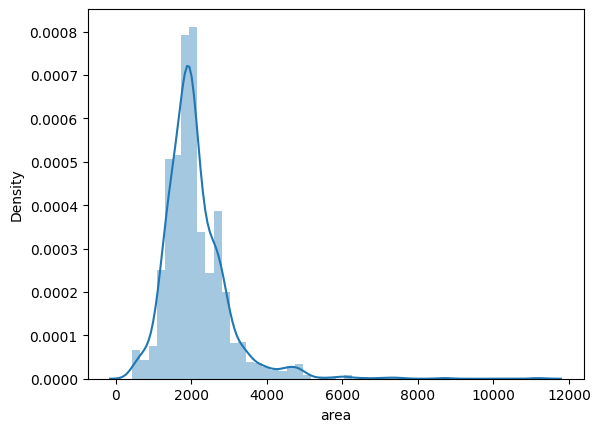

In [ ]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

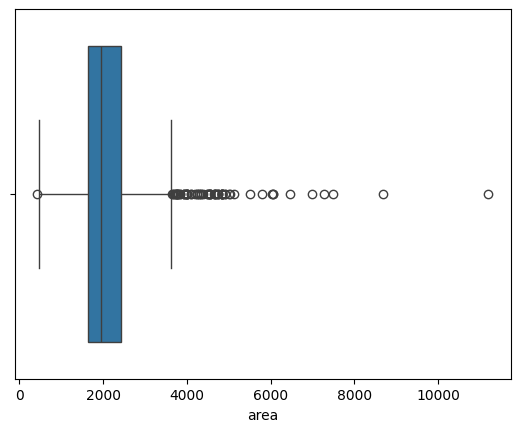

In [ ]:
sns.boxplot(x=df['area'])

In [ ]:
df['area'].describe()

,area
count,1539.000000
mean,2106.784925
std,850.046707
min,431.000000
25%,1630.000000
50%,1950.000000
75%,2427.500000
max,11200.000000


In [ ]:
df[df['area'] > 5500]

,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,latitude,longitude
11,indiabulls enigma,Sector 110,10.05,13400.0,7500,Super Built-up area 7500(696.77 sq.m.) sqft,5,6,3+,20,North-East,Relatively New,7500.0,NaN,NaN,1,1,1,1,1,Semi-Furnished,0,28.502392,77.011144
235,central park resorts,Sector 48,32.00,36849.0,8684,Carpet area: 8684 (806.77 sq.m.) sqft,4,6,2,16,North-East,Relatively New,NaN,NaN,8684.0,1,1,0,1,0,Furnished,3,28.424673,77.034182
320,krrish provence estate,Gwal Pahari,8.50,14655.0,5800,Carpet area: 5800 (538.84 sq.m.) sqft,4,4,3+,1,East,New Property,NaN,NaN,5800.0,0,1,0,0,1,Semi-Furnished,14,28.431234,77.142203
328,trump tower,Sector 65,23.00,38017.0,6050,Super Built-up area 6050(562.06 sq.m.)Built-up...,4,6,3+,22,North,New Property,6050.0,5000.00,4800.0,0,1,0,0,0,Unknown,15,28.399938,77.071545
594,experion windchants,Sector 112,12.00,18544.0,6471,Super Built-up area 6471(601.18 sq.m.)Built-up...,5,5,3+,25,North-East,Relatively New,6471.0,4525.93,3000.0,1,1,1,1,0,Semi-Furnished,0,28.518345,77.015362
829,ambience caitriona,DLF Phase 3,17.50,25000.0,7000,Super Built-up area 7000(650.32 sq.m.)Carpet a...,4,5,3,6,East,Moderately Old,7000.0,NaN,5000.0,1,1,1,1,0,Furnished,0,28.503070,77.100502
1083,adani m2k oyster grande,Sector 102,9.95,13662.0,7283,Super Built-up area 7283(676.61 sq.m.) sqft,5,6,3+,23,North-East,New Property,7283.0,NaN,NaN,0,1,1,0,0,Semi-Furnished,24,28.481464,76.973762
1118,m3m golfestate,Sector 65,33.67,30062.0,11200,Super Built-up area 11200(1040.51 sq.m.) sqft,7,8,3+,25,North-East,Relatively New,11200.0,NaN,NaN,1,1,0,1,1,Furnished,0,28.401343,77.068628
1319,diamond court,MG Road,12.50,20689.0,6042,Super Built-up area 6042(561.32 sq.m.) sqft,5,6,3+,5,North,Moderately Old,6042.0,NaN,NaN,1,0,0,0,0,Unknown,0,28.476538,77.073908
1499,trump tower,Sector 65,22.00,36364.0,6050,Super Built-up area 6050(562.06 sq.m.)Carpet a...,4,4,3+,23,East,New Property,6050.0,NaN,3797.0,0,1,0,0,0,Semi-Furnished,0,28.398113,77.072456


In [ ]:
df = df[df['area'] < 5500]

/tmp/ipykernel_11640/91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

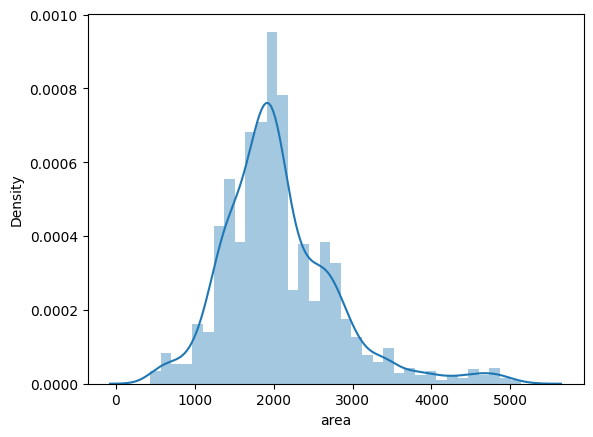

In [ ]:
sns.distplot(df['area'])

<Axes: ylabel='area'>

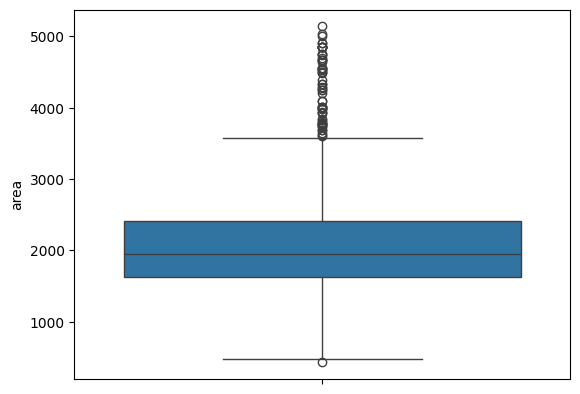

In [ ]:
sns.boxplot(df['area'])

In [ ]:
df.shape

(1528, 24)

In [ ]:
df['area'].describe()

,area
count,1528.000000
mean,2071.179319
std,729.595261
min,431.000000
25%,1629.750000
50%,1950.000000
75%,2410.000000
max,5138.000000


# Bedroom

/tmp/ipykernel_11640/1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

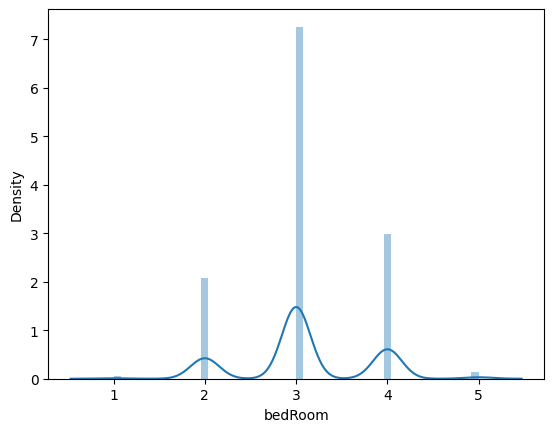

In [ ]:
sns.distplot(df['bedRoom'])

<Axes: ylabel='bedRoom'>

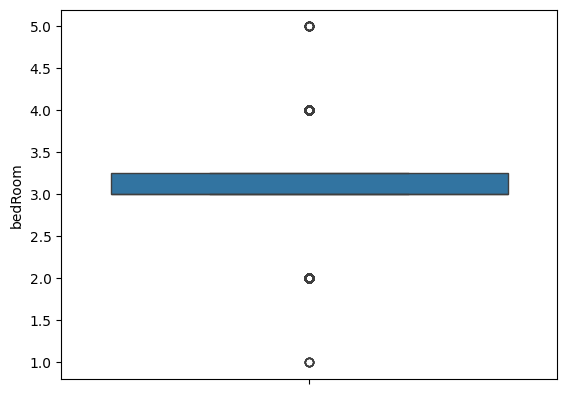

In [ ]:
sns.boxplot(df['bedRoom'])

In [ ]:
df['bedRoom'].describe()

,bedRoom
count,1528.000000
mean,3.088351
std,0.677582
min,1.000000
25%,3.000000
50%,3.000000
75%,3.250000
max,5.000000


# Bathroom

/tmp/ipykernel_11640/2904465235.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bathroom'])


<Axes: xlabel='bathroom', ylabel='Density'>

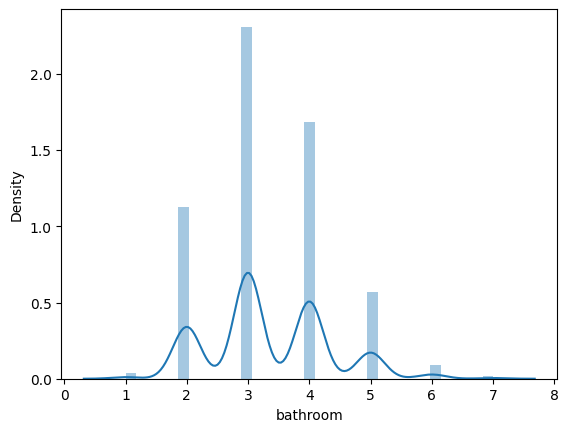

In [ ]:
sns.distplot(df['bathroom'])

<Axes: ylabel='bathroom'>

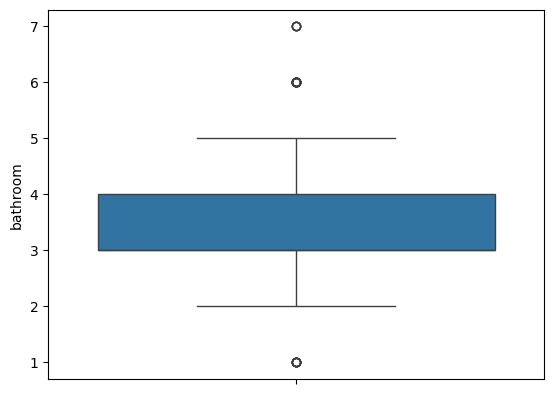

In [ ]:
sns.boxplot(df['bathroom'])

In [ ]:
df[df['bathroom'] > 6]

,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,latitude,longitude
104,emaar palm gardens,Sector 83,4.45,11867.0,3750,Super Built-up area 3750(348.39 sq.m.)Built-up...,5,7,3+,14,East,Relatively New,3750.0,3000.0,2437.0,0,1,0,0,0,Unknown,0,28.395476,76.975240
496,pioneer urban presidia,Sector 62,12.25,27042.0,4530,Super Built-up area 4530(420.85 sq.m.)Carpet a...,5,7,3+,20,East,Relatively New,4530.0,NaN,3150.0,1,1,0,1,1,Furnished,3,28.412125,77.089800
768,indiabulls centrum park,Sector 103,5.70,11633.0,4900,Super Built-up area 4900(455.22 sq.m.)Built-up...,4,7,3+,16,North-East,Relatively New,4900.0,4600.0,4500.0,1,1,0,1,0,Semi-Furnished,22,28.497705,76.982092
885,vipul belmonte,Sector 53,13.50,34395.0,3925,Super Built-up area 3925(364.64 sq.m.)Carpet a...,5,7,3+,10,North-East,Old Property,3925.0,NaN,2747.5,0,1,0,0,0,Furnished,0,28.440633,77.101733


# super built up area

/tmp/ipykernel_11640/4184943455.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['super_built_up_area'])


<Axes: xlabel='super_built_up_area', ylabel='Density'>

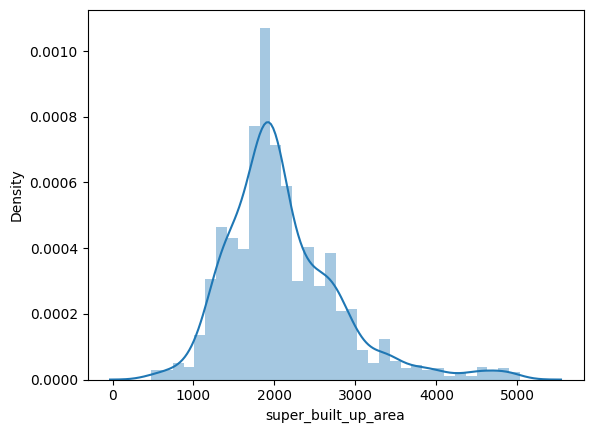

In [ ]:
sns.distplot(df['super_built_up_area'])

<Axes: ylabel='super_built_up_area'>

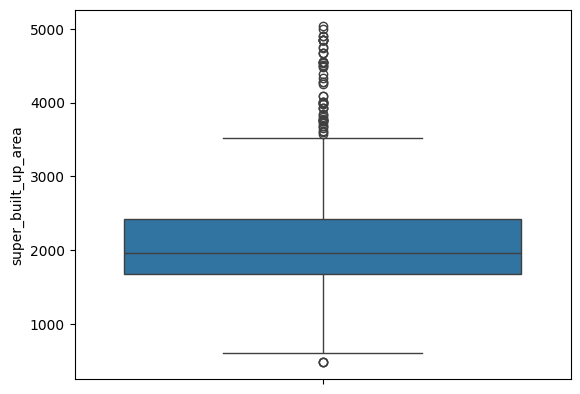

In [ ]:
sns.boxplot(df['super_built_up_area'])

In [ ]:
df['super_built_up_area'].describe()

,super_built_up_area
count,1316.000000
mean,2100.923754
std,709.631921
min,476.000000
25%,1678.750000
50%,1955.000000
75%,2423.500000
max,5033.000000


# built up area

/tmp/ipykernel_11640/3494228458.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['built_up_area'])


<Axes: xlabel='built_up_area', ylabel='Density'>

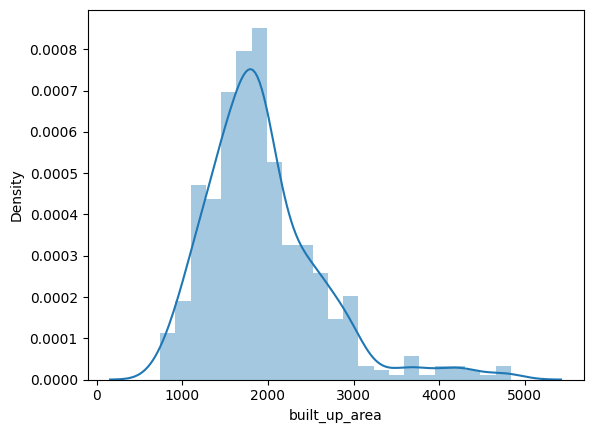

In [ ]:
sns.distplot(df['built_up_area'])

<Axes: ylabel='built_up_area'>

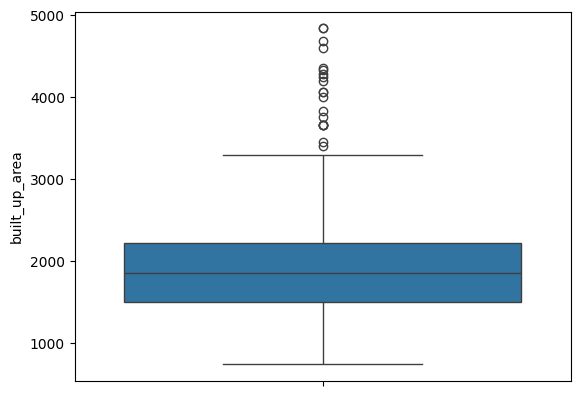

In [ ]:
sns.boxplot(df['built_up_area'])

# carpet area

/tmp/ipykernel_11640/3905767603.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['carpet_area'])


<Axes: xlabel='carpet_area', ylabel='Density'>

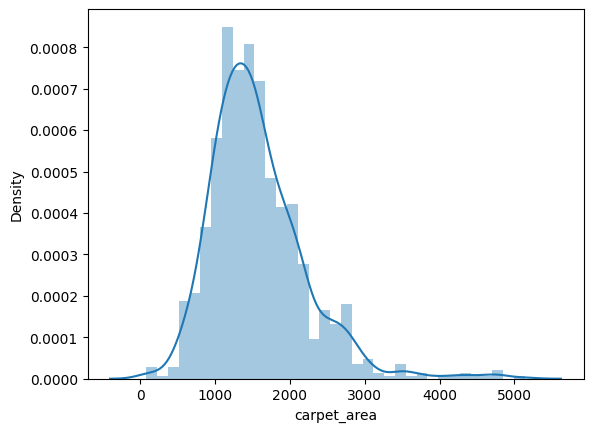

In [ ]:
sns.distplot(df['carpet_area'])

<Axes: ylabel='carpet_area'>

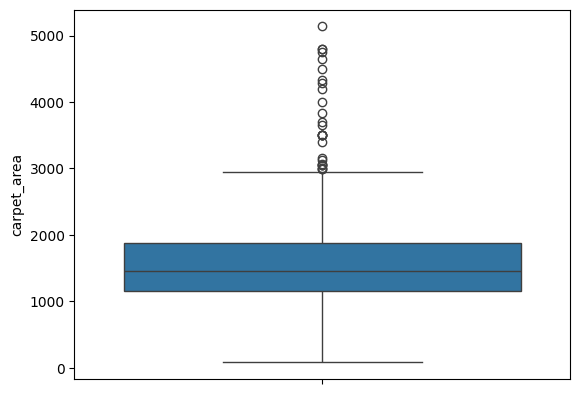

In [ ]:
sns.boxplot(df['carpet_area'])

# luxury score

/tmp/ipykernel_11640/3385064764.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['luxury_score'])


<Axes: xlabel='luxury_score', ylabel='Density'>

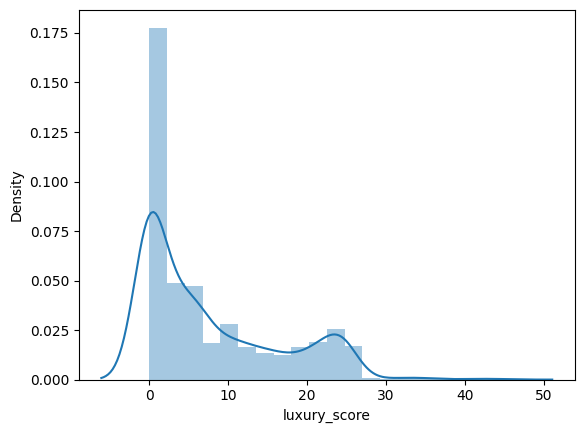

In [ ]:
sns.distplot(df['luxury_score'])

<Axes: ylabel='luxury_score'>

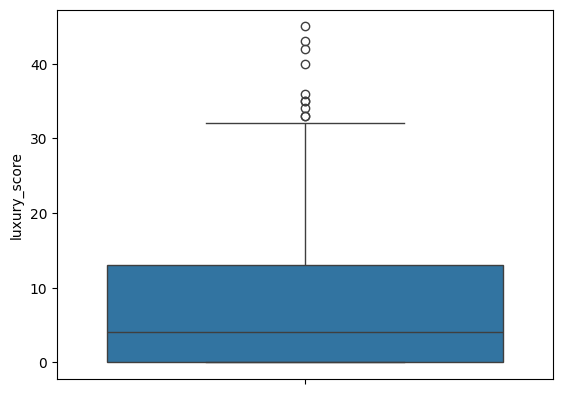

In [ ]:
sns.boxplot(df['luxury_score'])

In [ ]:
df.shape

(1528, 24)

In [ ]:
df['price_per_sqft'] = round((df['price']*10000000)/df['area'])

/tmp/ipykernel_11640/2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

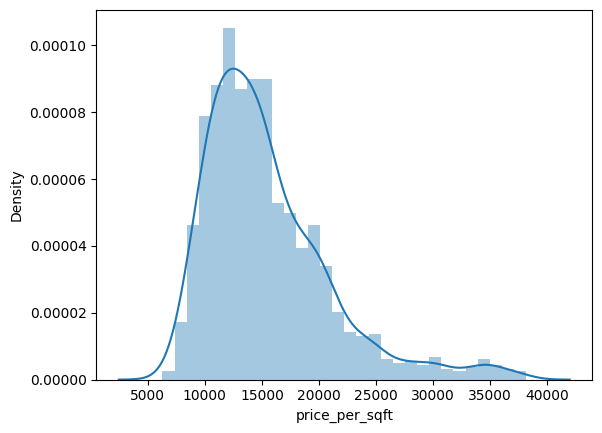

In [ ]:
sns.distplot(df['price_per_sqft'])

<Axes: ylabel='price_per_sqft'>

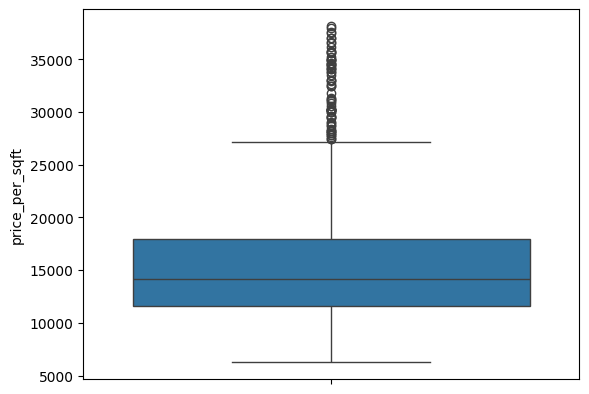

In [ ]:
sns.boxplot(df['price_per_sqft'])

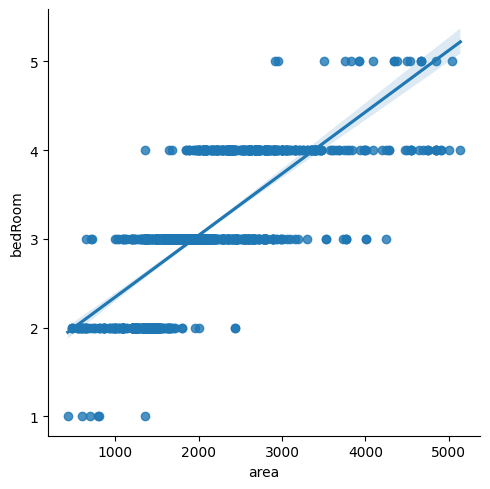

In [ ]:
sns.lmplot(data=df, x='area', y='bedRoom')

In [ ]:
df.to_csv('data_for_viz.csv',index=False)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1528 entries, 1 to 1562
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   society              1528 non-null   object 
 1   sector               1528 non-null   object 
 2   price                1528 non-null   float64
 3   price_per_sqft       1528 non-null   float64
 4   area                 1528 non-null   int64  
 5   areaWithType         1528 non-null   object 
 6   bedRoom              1528 non-null   int64  
 7   bathroom             1528 non-null   int64  
 8   balcony              1528 non-null   object 
 9   floorNum             1528 non-null   object 
 10  facing               1528 non-null   object 
 11  agePossession        1528 non-null   object 
 12  super_built_up_area  1316 non-null   float64
 13  built_up_area        500 non-null    float64
 14  carpet_area          1002 non-null   float64
 15  study room           1528 non-null   int64 